# Imports

In [138]:
%load_ext autoreload
%autoreload 2
import time

import jax
import matplotlib.pyplot as plt

from eci.adapter import SimulationAdapter
from eci.environment import Environment
from eci.visualizer import SimulationVisualizer
from eci.voting_system.plurality import _vote_plurality

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parameters

In [139]:
NUM_VOTERS = 100
NUM_CANDIDATES = 3
NUM_PREFERENCES = 2
NUM_SIMULATIONS = 100  # the node trajectories

# Environement

In [140]:
env = Environment(
    num_voters=NUM_VOTERS,
    num_candidates=NUM_CANDIDATES,
    num_preferences=NUM_PREFERENCES,
)
env.num_simulations = NUM_SIMULATIONS

# Changing preferences of two groups

We can access parameters of the preference distribution and modify them using:

In [141]:
env.voters[0].preferences  # access agent 0
env.voters[0].preferences["mean"][0]  # access mean of preference 0
env.voters[0].preferences["precision"][0]  # access precision of preference 0

Array(0.74241656, dtype=float32)

We can plot the current distribution of candidate et voters preferences

/Users/sylvainestebe/Code/european-city-inference/src/eci/visualizer.py:84: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


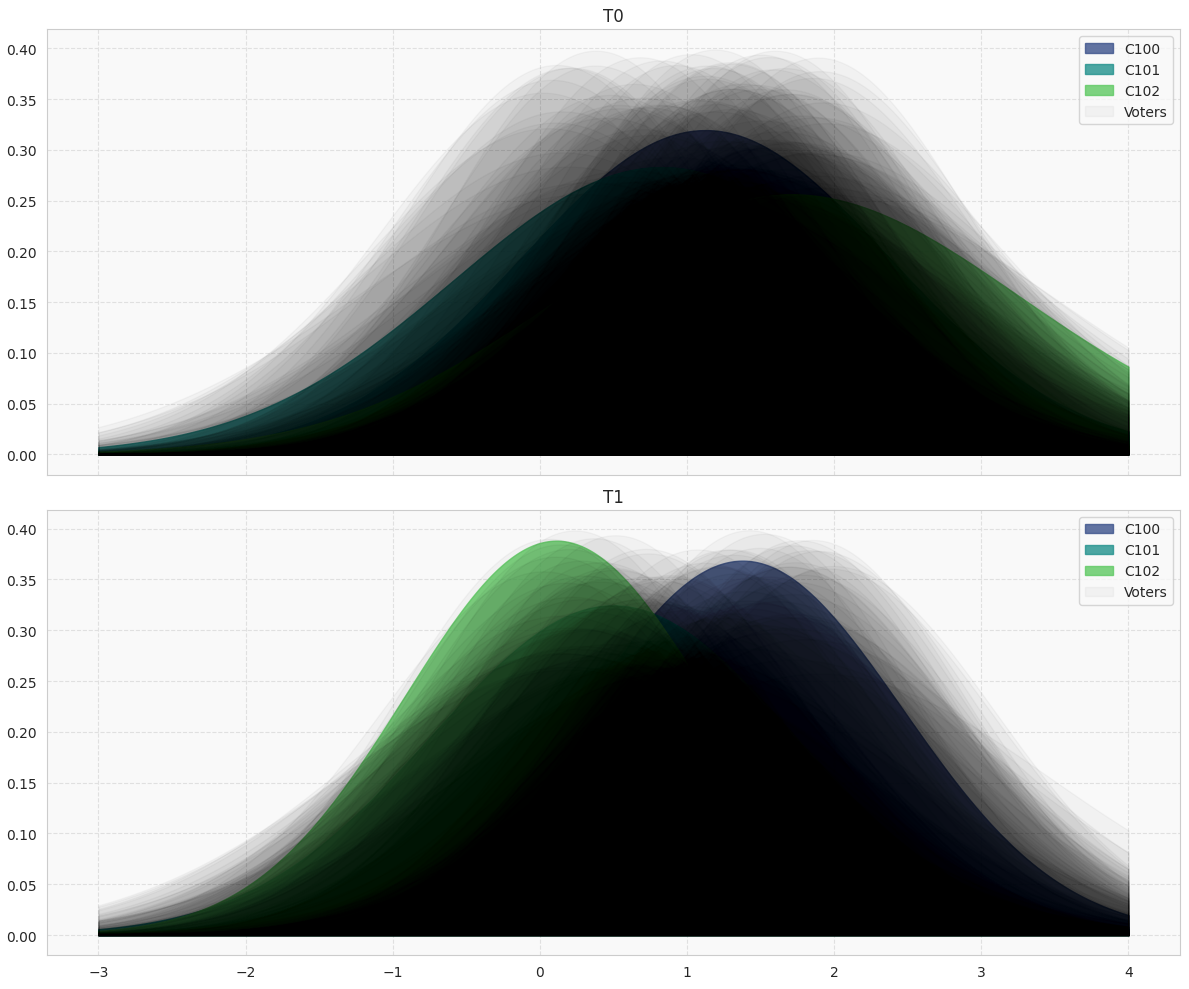

In [142]:
# 1. Initialisation viz and adapter
viz = SimulationVisualizer()
adapter = SimulationAdapter()
pref_data = adapter.prepare_preference_data(env)
fig, ax1 = viz.plot_preference_distributions(pref_data)

Then we can change the distribution of voters

In [143]:
env.voters[0].preferences["mean"][0]
env.voters[0].preferences["mean"] = env.voters[0].preferences["mean"].at[1].set(-1)
env.voters[0].preferences["mean"][1]

Array(-1., dtype=float32)

In [144]:
ID_THRESHOLD = 25

for voter in env.voters:
    if voter.id > ID_THRESHOLD:
        # This loop sets *every* preference index for this voter
        for preference_ixd in range(NUM_PREFERENCES):
            voter.preferences["mean"] = (
                voter.preferences["mean"].at[preference_ixd].set(3.0)
            )
            voter.preferences["precision"] = (
                voter.preferences["precision"].at[preference_ixd].set(1.5)
            )
    else:
        for preference_ixd in range(NUM_PREFERENCES):
            voter.preferences["mean"] = (
                voter.preferences["mean"].at[preference_ixd].set(-3.0)
            )
            voter.preferences["precision"] = (
                voter.preferences["precision"].at[preference_ixd].set(1.3)
            )

In [145]:
# Do the same for candidates
env.candidates[0].policy["mean"] = (
    env.candidates[0].policy["mean"].at[0].set(2.0).at[1].set(2.0)
)
env.candidates[0].policy["precision"] = (
    env.candidates[0].policy["precision"].at[0].set(1.0).at[1].set(1.0)
)

In [146]:
# Do the same for candidates
env.candidates[1].policy["mean"] = (
    env.candidates[1].policy["mean"].at[0].set(-2.0).at[1].set(-2.0)
)
env.candidates[1].policy["precision"] = (
    env.candidates[1].policy["precision"].at[0].set(1.0).at[1].set(1.0)
)

/Users/sylvainestebe/Code/european-city-inference/src/eci/visualizer.py:84: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


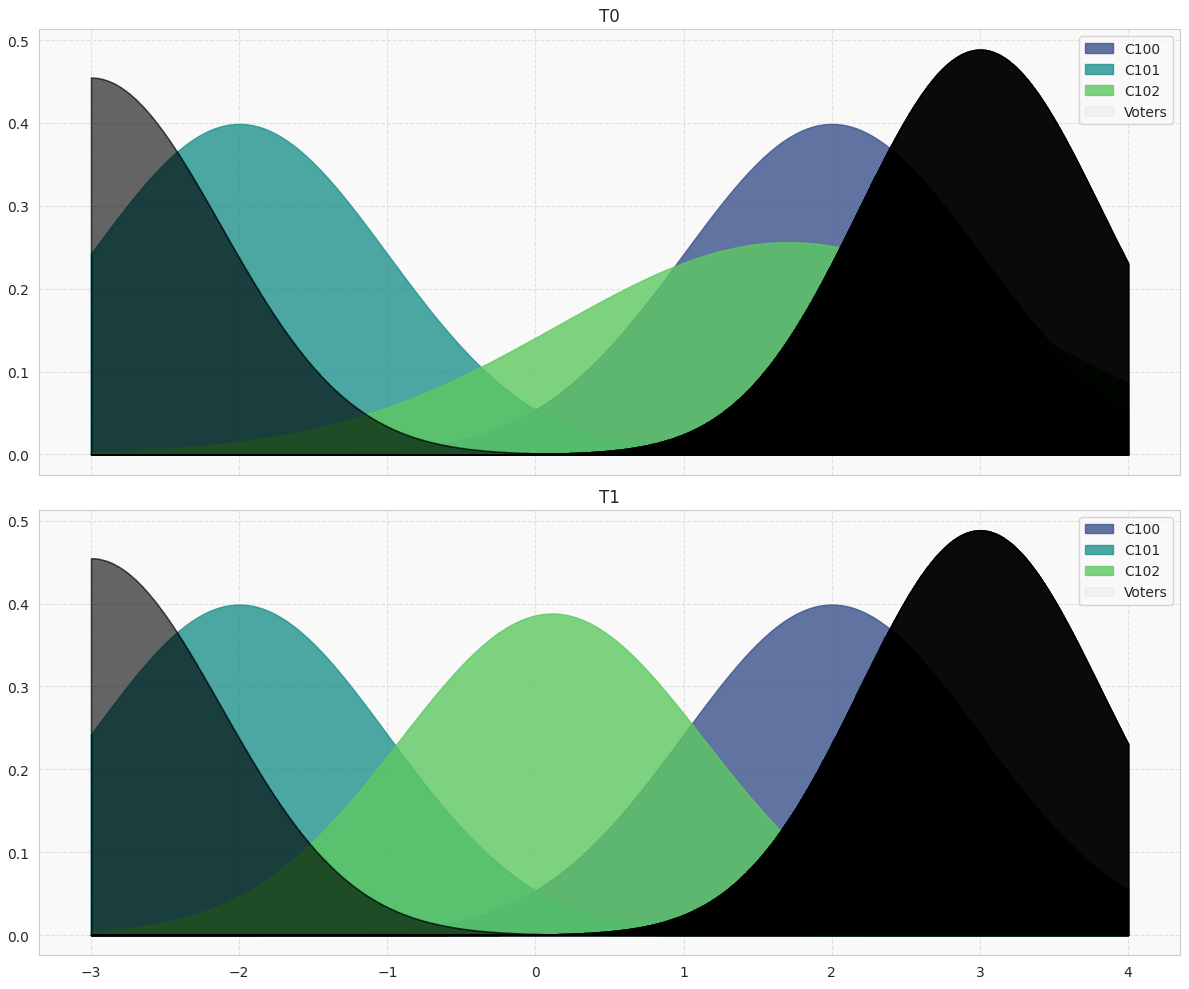

In [147]:
# 1. Initialisation viz and adapter
pref_data = adapter.prepare_preference_data(env)
fig, ax1 = viz.plot_preference_distributions(pref_data)

In [148]:
# Then we run the agent networks
env.initialize_network()

# Run simulation

In [149]:
# intiatialize random key
key = jax.random.PRNGKey(int(time.time()))
# run n simulations
sim = env.run_n_simulation(_vote_plurality, key, NUM_SIMULATIONS)
# update the agents with the results
env._update_agents()

In [150]:
# use result to create dataframe for plotting
env.df = env.create_data_frame()

/Users/sylvainestebe/Code/european-city-inference/src/eci/visualizer.py:269: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


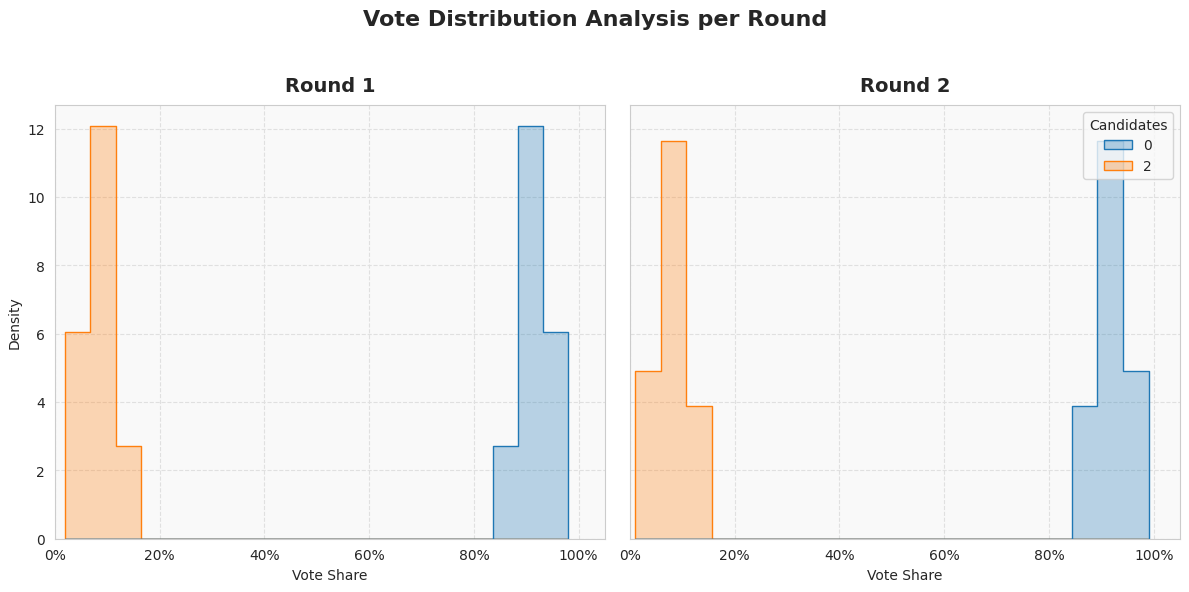

In [151]:
votes_data = adapter.extract_vote_counts(env.df)
fig, axes = viz.plot_vote_proportions(votes_data, plot_kind="histogram")
plt.show()